# 06 — Final Model Evaluation and Error Analysis

This notebook evaluates the out-of-fold predictions produced by Notebooks 04 and 05.

It is organized in the order we actually want to understand the models:

1. **Standard classification performance**
   - accuracy
   - balanced accuracy
   - precision
   - recall
   - F1
   - class-specific metrics
   - confusion matrices
   - ROC-AUC / ROC curves when continuous scores are available
2. **Ordinal performance**
   - ordinal MAE
   - quadratic weighted kappa
   - adjacent vs extreme errors
3. **Research comparisons**
   - nominal vs ordinal
   - RDKit vs Morgan
   - random vs scaffold
4. **Failure analysis**
   - difficult compounds
   - difficult scaffolds

### ROC-AUC rule

ROC-AUC requires continuous class scores or probabilities. It must not be calculated from hard predicted labels.

If the current prediction CSVs do not contain continuous scores for `No`, `Less`, and `Most`, this notebook will mark ROC-AUC as unavailable rather than produce a misleading result.


## 1. Imports and paths

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import t as student_t
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    cohen_kappa_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 120)

CLASS_ORDER = ["No", "Less", "Most"]
CLASS_TO_ORDER = {"No": 0, "Less": 1, "Most": 2}

candidate_roots = [Path.cwd()] + list(Path.cwd().parents)[:3]

PROJECT_ROOT = next(
    (
        p for p in candidate_roots
        if (p / "results/predictions/nominal_predictions.csv").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate completed outputs from Notebooks 04 and 05."
    )

TABLE_DIR = PROJECT_ROOT / "results/tables"
PRED_DIR = PROJECT_ROOT / "results/predictions"
SPLIT_DIR = PROJECT_ROOT / "data/splits"
FIG_DIR = PROJECT_ROOT / "results/figures/final"

FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction


## 2. Load predictions and standardize model-family names

In [3]:
nominal_predictions = pd.read_csv(
    PRED_DIR / "nominal_predictions.csv"
)

ordinal_predictions = pd.read_csv(
    PRED_DIR / "ordinal_predictions.csv"
)

population = pd.read_csv(
    SPLIT_DIR / "concern_modelling_population.csv"
)

NOMINAL_MAP = {
    "logistic_regression": "logistic",
    "svm": "svm",
    "random_forest": "random_forest",
    "hist_gradient_boosting": "hist_gradient_boosting",
}

ORDINAL_MAP = {
    "ordinal_logistic": "logistic",
    "ordinal_svm": "svm",
    "ordinal_random_forest": "random_forest",
    "ordinal_hist_gradient_boosting": "hist_gradient_boosting",
}

nominal_predictions["formulation"] = "nominal"
ordinal_predictions["formulation"] = "ordinal"

nominal_predictions["model_family"] = (
    nominal_predictions["model"].map(NOMINAL_MAP)
)

ordinal_predictions["model_family"] = (
    ordinal_predictions["model"].map(ORDINAL_MAP)
)

predictions = pd.concat(
    [nominal_predictions, ordinal_predictions],
    ignore_index=True,
)

CONFIG_KEYS = [
    "formulation",
    "representation",
    "split_regime",
    "model_family",
]

print("Nominal prediction rows:", len(nominal_predictions))
print("Ordinal prediction rows:", len(ordinal_predictions))
print("Combined rows:", len(predictions))


Nominal prediction rows: 14176
Ordinal prediction rows: 14176
Combined rows: 28352


## 3. Validate that all benchmark configurations completed

In [4]:
expected_n = len(population)
expected_configs = 2 * 2 * 2 * 4

validation = (
    predictions
    .groupby(CONFIG_KEYS)
    .agg(
        n_predictions=("feature_row", "size"),
        n_unique_compounds=("feature_row", "nunique"),
        n_outer_folds=("outer_fold", "nunique"),
    )
    .reset_index()
)

display(validation)

if len(validation) != expected_configs:
    raise RuntimeError(
        f"Expected {expected_configs} configurations, found {len(validation)}."
    )

if not (validation["n_predictions"] == expected_n).all():
    raise RuntimeError(
        "At least one configuration is missing predictions."
    )

if not (validation["n_unique_compounds"] == expected_n).all():
    raise RuntimeError(
        "At least one configuration has duplicate or missing compounds."
    )

if not (validation["n_outer_folds"] == 5).all():
    raise RuntimeError(
        "At least one configuration does not contain all five outer folds."
    )

print("Validation passed.")
print(
    f"All 32 configurations contain one out-of-fold prediction "
    f"for all {expected_n} compounds."
)


,formulation,representation,split_regime,model_family,n_predictions,n_unique_compounds,n_outer_folds
0,nominal,morgan_ecfp4,random,hist_gradient_boosting,886,886,5
1,nominal,morgan_ecfp4,random,logistic,886,886,5
2,nominal,morgan_ecfp4,random,random_forest,886,886,5
3,nominal,morgan_ecfp4,random,svm,886,886,5
4,nominal,morgan_ecfp4,scaffold,hist_gradient_boosting,886,886,5
5,nominal,morgan_ecfp4,scaffold,logistic,886,886,5
6,nominal,morgan_ecfp4,scaffold,random_forest,886,886,5
7,nominal,morgan_ecfp4,scaffold,svm,886,886,5
8,nominal,rdkit,random,hist_gradient_boosting,886,886,5
9,nominal,rdkit,random,logistic,886,886,5


Validation passed.
All 32 configurations contain one out-of-fold prediction for all 886 compounds.


# Part A — Standard Model Assessment

## 4. Overall classification metrics

For every model configuration we calculate:

- **Accuracy**
- **Balanced accuracy**
- **Macro precision**
- **Macro recall**
- **Macro F1**
- **Weighted F1**
- **Ordinal MAE**
- **Quadratic weighted kappa (QWK)**

Balanced accuracy and macro F1 remain the primary classification metrics because the three classes are not equally frequent.


In [5]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_order = np.array(
        [CLASS_TO_ORDER[x] for x in y_true],
        dtype=int,
    )
    pred_order = np.array(
        [CLASS_TO_ORDER[x] for x in y_pred],
        dtype=int,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            labels=CLASS_ORDER,
            average="macro",
            zero_division=0,
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            labels=CLASS_ORDER,
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=CLASS_ORDER,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=CLASS_ORDER,
            average="weighted",
            zero_division=0,
        ),
        "ordinal_mae": mean_absolute_error(
            true_order,
            pred_order,
        ),
        "qwk": cohen_kappa_score(
            true_order,
            pred_order,
            weights="quadratic",
        ),
    }


overall_rows = []

for keys, group in predictions.groupby(CONFIG_KEYS, sort=False):
    row = dict(zip(CONFIG_KEYS, keys))
    row.update(
        calculate_metrics(
            group["true_class"],
            group["predicted_class"],
        )
    )
    overall_rows.append(row)

overall_metrics = pd.DataFrame(overall_rows)

overall_metrics = overall_metrics.sort_values(
    ["split_regime", "balanced_accuracy"],
    ascending=[True, False],
).reset_index(drop=True)

overall_metrics.to_csv(
    TABLE_DIR / "standard_model_assessment_oof.csv",
    index=False,
)

display(
    overall_metrics[
        [
            "formulation",
            "representation",
            "split_regime",
            "model_family",
            "accuracy",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "ordinal_mae",
            "qwk",
        ]
    ].round(3)
)


,formulation,representation,split_regime,model_family,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,ordinal_mae,qwk
0,nominal,morgan_ecfp4,random,random_forest,0.537,0.537,0.528,0.537,0.530,0.538,0.554,0.420
1,nominal,morgan_ecfp4,random,svm,0.536,0.524,0.527,0.524,0.525,0.538,0.546,0.402
2,nominal,morgan_ecfp4,random,logistic,0.521,0.517,0.512,0.517,0.514,0.523,0.570,0.388
3,ordinal,morgan_ecfp4,random,svm,0.525,0.512,0.523,0.512,0.515,0.527,0.547,0.395
4,ordinal,morgan_ecfp4,random,logistic,0.519,0.511,0.508,0.511,0.509,0.519,0.571,0.383
5,ordinal,rdkit,random,hist_gradient_boosting,0.526,0.505,0.524,0.505,0.510,0.525,0.542,0.388
6,nominal,rdkit,random,svm,0.505,0.505,0.498,0.505,0.498,0.507,0.621,0.321
7,ordinal,morgan_ecfp4,random,hist_gradient_boosting,0.516,0.504,0.503,0.504,0.503,0.515,0.578,0.367
8,ordinal,morgan_ecfp4,random,random_forest,0.518,0.504,0.517,0.504,0.507,0.520,0.551,0.393
9,nominal,rdkit,random,random_forest,0.520,0.500,0.506,0.500,0.502,0.519,0.571,0.349


## 5. Per-class precision, recall, F1, and specificity

In [6]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        average=None,
        zero_division=0,
    )

    recall = recall_score(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        average=None,
        zero_division=0,
    )

    f1 = f1_score(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
        average=None,
        zero_division=0,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_ORDER,
    )

    rows = []
    total = cm.sum()

    for i, class_name in enumerate(CLASS_ORDER):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        rows.append({
            "class": class_name,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "specificity": specificity,
            "support": int(cm[i, :].sum()),
        })

    return rows


rows = []

for keys, group in predictions.groupby(CONFIG_KEYS, sort=False):
    base = dict(zip(CONFIG_KEYS, keys))

    for result in class_metrics(
        group["true_class"],
        group["predicted_class"],
    ):
        rows.append({**base, **result})

classwise_metrics = pd.DataFrame(rows)

classwise_metrics.to_csv(
    TABLE_DIR / "classwise_model_metrics.csv",
    index=False,
)

display(
    classwise_metrics.sort_values(
        CONFIG_KEYS + ["class"]
    ).round(3)
)


,formulation,representation,split_regime,model_family,class,precision,recall,f1,specificity,support
34,nominal,morgan_ecfp4,random,hist_gradient_boosting,Less,0.479,0.482,0.480,0.689,330
35,nominal,morgan_ecfp4,random,hist_gradient_boosting,Most,0.425,0.427,0.426,0.825,206
33,nominal,morgan_ecfp4,random,hist_gradient_boosting,No,0.588,0.583,0.585,0.733,350
25,nominal,morgan_ecfp4,random,logistic,Less,0.480,0.464,0.471,0.701,330
26,nominal,morgan_ecfp4,random,logistic,Most,0.440,0.495,0.466,0.809,206
24,nominal,morgan_ecfp4,random,logistic,No,0.618,0.591,0.604,0.761,350
31,nominal,morgan_ecfp4,random,random_forest,Less,0.502,0.439,0.468,0.741,330
32,nominal,morgan_ecfp4,random,random_forest,Most,0.440,0.549,0.488,0.788,206
30,nominal,morgan_ecfp4,random,random_forest,No,0.641,0.623,0.632,0.772,350
28,nominal,morgan_ecfp4,random,svm,Less,0.489,0.524,0.506,0.674,330


## 6. Fold-level performance and variability

The previous table uses all out-of-fold predictions together.

For uncertainty we calculate the same metrics separately within each outer fold and summarize the five fold values as:

- mean
- standard deviation
- descriptive 95% t-based confidence interval


In [7]:
FOLD_KEYS = CONFIG_KEYS + ["outer_fold"]

rows = []

for keys, group in predictions.groupby(FOLD_KEYS, sort=False):
    row = dict(zip(FOLD_KEYS, keys))
    row.update(
        calculate_metrics(
            group["true_class"],
            group["predicted_class"],
        )
    )
    rows.append(row)

fold_metrics = pd.DataFrame(rows)

fold_metrics.to_csv(
    TABLE_DIR / "standard_model_assessment_by_fold.csv",
    index=False,
)


def mean_sd_ci(values):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    n = len(values)

    mean = float(np.mean(values))

    if n < 2:
        return mean, np.nan, np.nan, np.nan

    sd = float(np.std(values, ddof=1))
    se = sd / np.sqrt(n)
    critical = student_t.ppf(0.975, df=n - 1)
    margin = critical * se

    return mean, sd, mean - margin, mean + margin


SUMMARY_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "ordinal_mae",
    "qwk",
]

rows = []

for keys, group in fold_metrics.groupby(CONFIG_KEYS, sort=False):
    row = dict(zip(CONFIG_KEYS, keys))

    for metric in SUMMARY_METRICS:
        mean, sd, low, high = mean_sd_ci(group[metric])

        row[f"{metric}_mean"] = mean
        row[f"{metric}_sd"] = sd
        row[f"{metric}_ci95_low"] = low
        row[f"{metric}_ci95_high"] = high

    rows.append(row)

benchmark_summary = pd.DataFrame(rows)

benchmark_summary = benchmark_summary.sort_values(
    ["split_regime", "balanced_accuracy_mean"],
    ascending=[True, False],
).reset_index(drop=True)

benchmark_summary.to_csv(
    TABLE_DIR / "final_benchmark_summary.csv",
    index=False,
)

display(
    benchmark_summary[
        [
            "formulation",
            "representation",
            "split_regime",
            "model_family",
            "accuracy_mean",
            "balanced_accuracy_mean",
            "macro_precision_mean",
            "macro_recall_mean",
            "macro_f1_mean",
            "weighted_f1_mean",
            "ordinal_mae_mean",
            "qwk_mean",
        ]
    ].round(3)
)


,formulation,representation,split_regime,model_family,accuracy_mean,balanced_accuracy_mean,macro_precision_mean,macro_recall_mean,macro_f1_mean,weighted_f1_mean,ordinal_mae_mean,qwk_mean
0,nominal,morgan_ecfp4,random,random_forest,0.537,0.537,0.531,0.537,0.529,0.537,0.554,0.421
1,nominal,morgan_ecfp4,random,svm,0.536,0.524,0.531,0.524,0.523,0.537,0.546,0.401
2,nominal,morgan_ecfp4,random,logistic,0.521,0.517,0.514,0.517,0.513,0.522,0.570,0.387
3,ordinal,morgan_ecfp4,random,svm,0.525,0.512,0.525,0.512,0.514,0.527,0.547,0.395
4,ordinal,morgan_ecfp4,random,logistic,0.519,0.511,0.507,0.511,0.508,0.518,0.571,0.383
5,ordinal,rdkit,random,hist_gradient_boosting,0.526,0.506,0.527,0.506,0.509,0.524,0.542,0.389
6,nominal,rdkit,random,svm,0.505,0.505,0.502,0.505,0.498,0.507,0.621,0.321
7,ordinal,morgan_ecfp4,random,hist_gradient_boosting,0.516,0.504,0.506,0.504,0.502,0.514,0.578,0.368
8,ordinal,morgan_ecfp4,random,random_forest,0.518,0.504,0.519,0.504,0.506,0.519,0.551,0.393
9,nominal,rdkit,random,random_forest,0.520,0.501,0.508,0.501,0.502,0.519,0.571,0.349


## 7. Rank models separately under random and scaffold CV

In [8]:
for split_name in ["random", "scaffold"]:
    print()
    print("=" * 90)
    print(split_name.upper(), "CV")

    ranking = (
        benchmark_summary.loc[
            benchmark_summary["split_regime"] == split_name,
            [
                "formulation",
                "representation",
                "model_family",
                "accuracy_mean",
                "balanced_accuracy_mean",
                "macro_precision_mean",
                "macro_recall_mean",
                "macro_f1_mean",
                "ordinal_mae_mean",
                "qwk_mean",
            ],
        ]
        .sort_values(
            "balanced_accuracy_mean",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    ranking.index = ranking.index + 1
    display(ranking.round(3))



RANDOM CV


,formulation,representation,model_family,accuracy_mean,balanced_accuracy_mean,macro_precision_mean,macro_recall_mean,macro_f1_mean,ordinal_mae_mean,qwk_mean
1,nominal,morgan_ecfp4,random_forest,0.537,0.537,0.531,0.537,0.529,0.554,0.421
2,nominal,morgan_ecfp4,svm,0.536,0.524,0.531,0.524,0.523,0.546,0.401
3,nominal,morgan_ecfp4,logistic,0.521,0.517,0.514,0.517,0.513,0.570,0.387
4,ordinal,morgan_ecfp4,svm,0.525,0.512,0.525,0.512,0.514,0.547,0.395
5,ordinal,morgan_ecfp4,logistic,0.519,0.511,0.507,0.511,0.508,0.571,0.383
6,ordinal,rdkit,hist_gradient_boosting,0.526,0.506,0.527,0.506,0.509,0.542,0.389
7,nominal,rdkit,svm,0.505,0.505,0.502,0.505,0.498,0.621,0.321
8,ordinal,morgan_ecfp4,hist_gradient_boosting,0.516,0.504,0.506,0.504,0.502,0.578,0.368
9,ordinal,morgan_ecfp4,random_forest,0.518,0.504,0.519,0.504,0.506,0.551,0.393
10,nominal,rdkit,random_forest,0.520,0.501,0.508,0.501,0.502,0.571,0.349



SCAFFOLD CV


,formulation,representation,model_family,accuracy_mean,balanced_accuracy_mean,macro_precision_mean,macro_recall_mean,macro_f1_mean,ordinal_mae_mean,qwk_mean
1,nominal,morgan_ecfp4,random_forest,0.520,0.512,0.507,0.512,0.505,0.609,0.320
2,ordinal,morgan_ecfp4,logistic,0.524,0.511,0.511,0.511,0.509,0.579,0.359
3,ordinal,morgan_ecfp4,hist_gradient_boosting,0.519,0.508,0.513,0.508,0.508,0.575,0.360
4,ordinal,rdkit,hist_gradient_boosting,0.527,0.504,0.529,0.504,0.507,0.545,0.379
5,nominal,morgan_ecfp4,logistic,0.516,0.502,0.504,0.502,0.500,0.595,0.332
6,nominal,rdkit,random_forest,0.523,0.502,0.511,0.502,0.501,0.574,0.340
7,nominal,rdkit,hist_gradient_boosting,0.520,0.500,0.504,0.500,0.500,0.585,0.331
8,ordinal,morgan_ecfp4,random_forest,0.507,0.499,0.504,0.499,0.498,0.576,0.378
9,nominal,morgan_ecfp4,hist_gradient_boosting,0.507,0.497,0.495,0.497,0.495,0.594,0.354
10,ordinal,morgan_ecfp4,svm,0.507,0.497,0.513,0.497,0.497,0.588,0.353


## 8. Standard performance figures

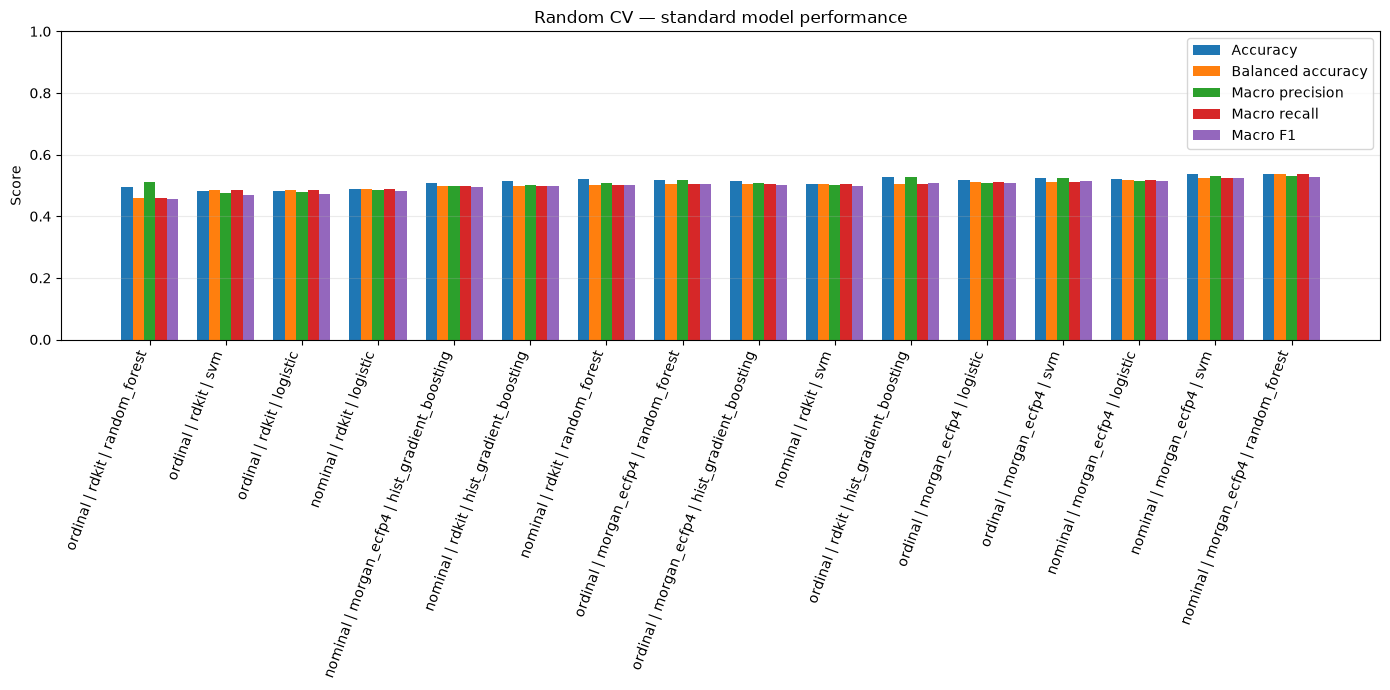

Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/results/figures/final/standard_metrics_random.png


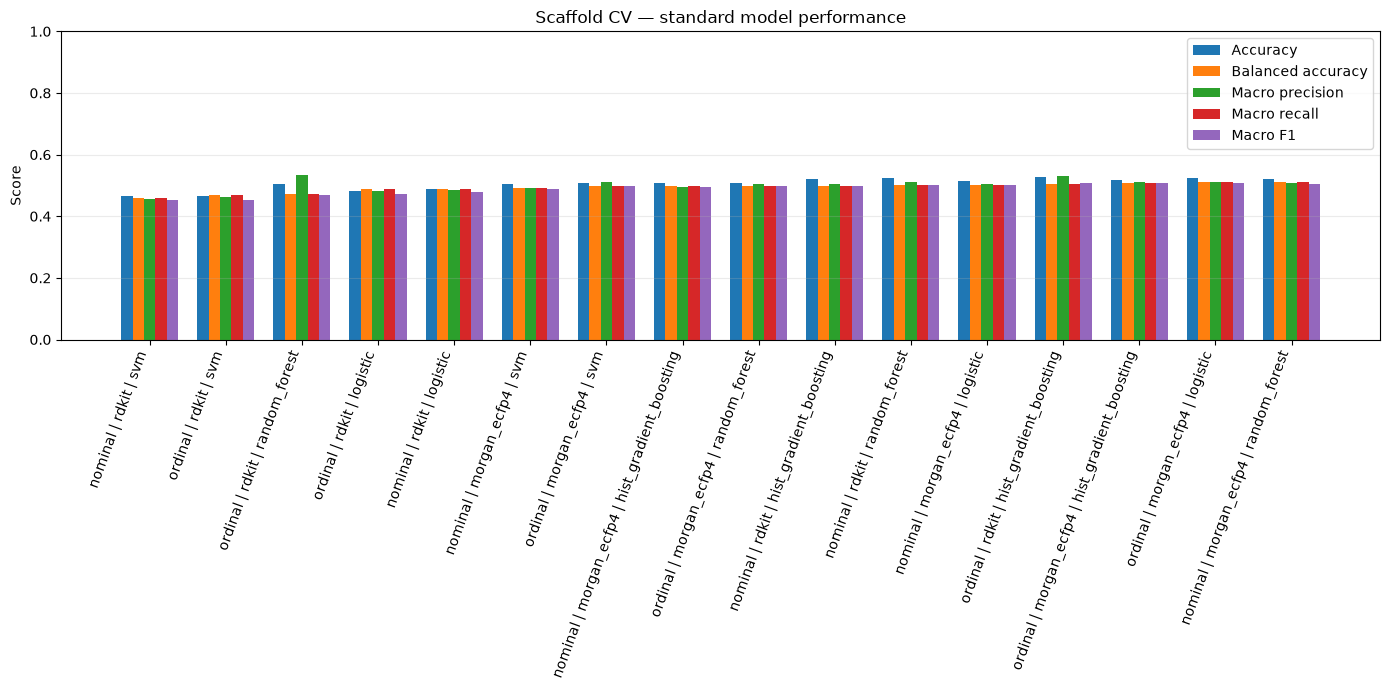

Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/results/figures/final/standard_metrics_scaffold.png


In [9]:
for split_name in ["random", "scaffold"]:
    plot_df = benchmark_summary.loc[
        benchmark_summary["split_regime"] == split_name
    ].copy()

    plot_df = plot_df.sort_values(
        "balanced_accuracy_mean"
    )

    plot_df["label"] = (
        plot_df["formulation"]
        + " | "
        + plot_df["representation"]
        + " | "
        + plot_df["model_family"]
    )

    metric_columns = [
        "accuracy_mean",
        "balanced_accuracy_mean",
        "macro_precision_mean",
        "macro_recall_mean",
        "macro_f1_mean",
    ]

    metric_labels = [
        "Accuracy",
        "Balanced accuracy",
        "Macro precision",
        "Macro recall",
        "Macro F1",
    ]

    x = np.arange(len(plot_df))
    width = 0.15

    fig, ax = plt.subplots(figsize=(14, 7))

    for i, (column, label) in enumerate(
        zip(metric_columns, metric_labels)
    ):
        offset = (
            i - (len(metric_columns) - 1) / 2
        ) * width

        ax.bar(
            x + offset,
            plot_df[column],
            width=width,
            label=label,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        plot_df["label"],
        rotation=70,
        ha="right",
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(
        f"{split_name.capitalize()} CV — standard model performance"
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()

    path = FIG_DIR / f"standard_metrics_{split_name}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


## 9. Best configuration under each split regime

In [10]:
best_configs = (
    benchmark_summary
    .sort_values(
        ["split_regime", "balanced_accuracy_mean"],
        ascending=[True, False],
    )
    .groupby("split_regime", as_index=False)
    .first()
)

best_configs.to_csv(
    TABLE_DIR / "best_configurations.csv",
    index=False,
)

display(
    best_configs[
        [
            "split_regime",
            "formulation",
            "representation",
            "model_family",
            "accuracy_mean",
            "balanced_accuracy_mean",
            "macro_precision_mean",
            "macro_recall_mean",
            "macro_f1_mean",
            "ordinal_mae_mean",
            "qwk_mean",
        ]
    ].round(3)
)


,split_regime,formulation,representation,model_family,accuracy_mean,balanced_accuracy_mean,macro_precision_mean,macro_recall_mean,macro_f1_mean,ordinal_mae_mean,qwk_mean
0,random,nominal,morgan_ecfp4,random_forest,0.537,0.537,0.531,0.537,0.529,0.554,0.421
1,scaffold,nominal,morgan_ecfp4,random_forest,0.520,0.512,0.507,0.512,0.505,0.609,0.320


## 10. Per-class precision / recall / F1 for the best models

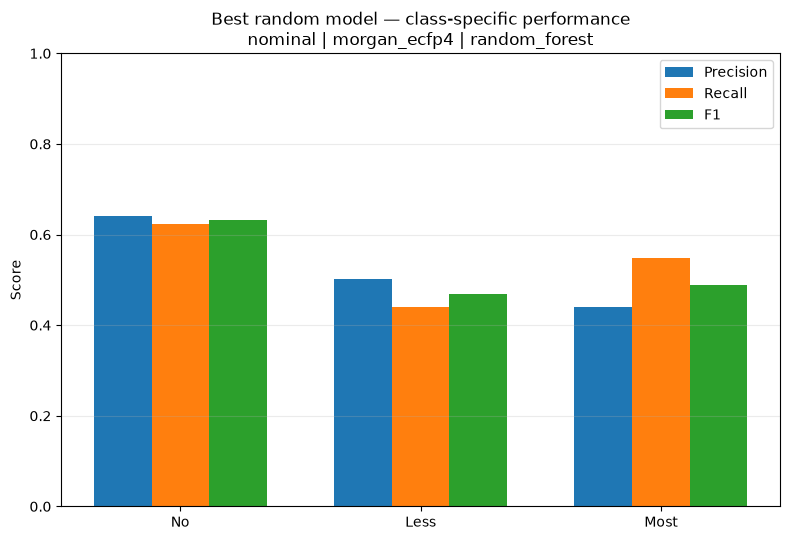

Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/results/figures/final/best_random_class_metrics.png


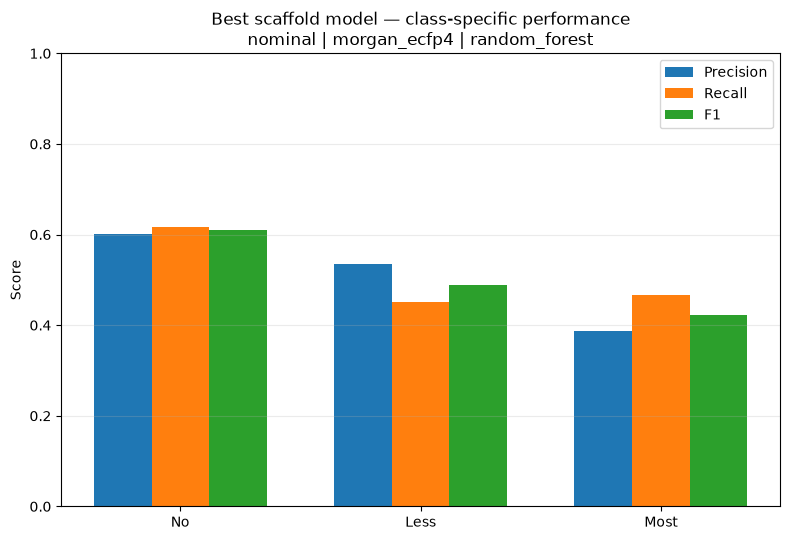

Saved: /home/gman/Documents/BS-Bioinformatics/dilirank2-prediction/results/figures/final/best_scaffold_class_metrics.png


In [11]:
for split_name in ["random", "scaffold"]:
    best = best_configs.loc[
        best_configs["split_regime"] == split_name
    ].iloc[0]

    subset = classwise_metrics.loc[
        (classwise_metrics["split_regime"] == split_name)
        & (classwise_metrics["formulation"] == best["formulation"])
        & (classwise_metrics["representation"] == best["representation"])
        & (classwise_metrics["model_family"] == best["model_family"])
    ].copy()

    subset["class"] = pd.Categorical(
        subset["class"],
        categories=CLASS_ORDER,
        ordered=True,
    )
    subset = subset.sort_values("class")

    x = np.arange(len(CLASS_ORDER))
    width = 0.24

    fig, ax = plt.subplots(figsize=(8, 5.5))

    ax.bar(
        x - width,
        subset["precision"],
        width=width,
        label="Precision",
    )

    ax.bar(
        x,
        subset["recall"],
        width=width,
        label="Recall",
    )

    ax.bar(
        x + width,
        subset["f1"],
        width=width,
        label="F1",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_ORDER)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(
        f"Best {split_name} model — class-specific performance\n"
        f"{best['formulation']} | "
        f"{best['representation']} | "
        f"{best['model_family']}"
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()

    path = FIG_DIR / f"best_{split_name}_class_metrics.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


## 11. Confusion matrices for the best random and scaffold models

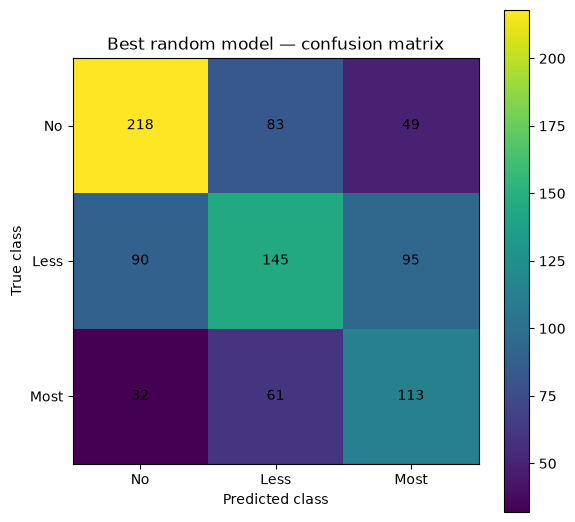

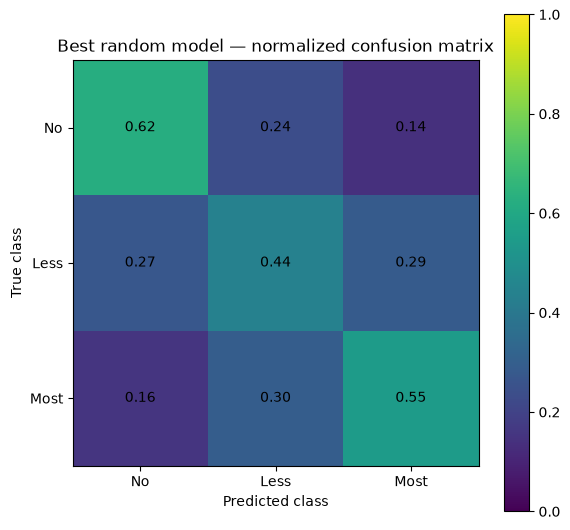

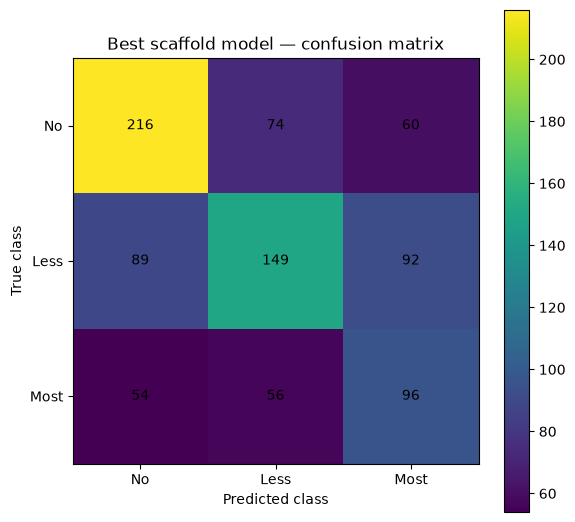

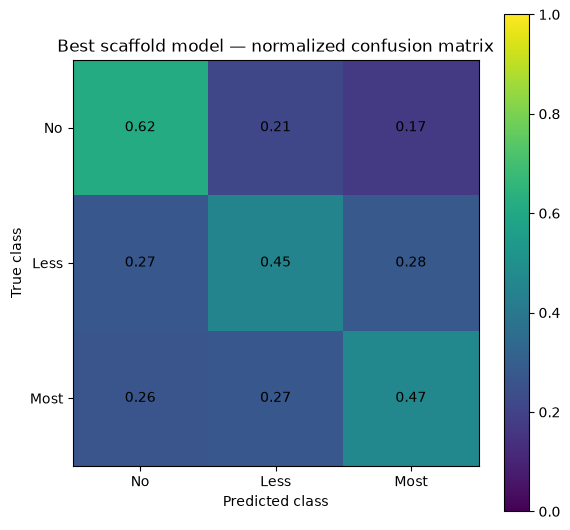

In [12]:
def best_prediction_subset(split_name):
    best = best_configs.loc[
        best_configs["split_regime"] == split_name
    ].iloc[0]

    subset = predictions.loc[
        (predictions["split_regime"] == split_name)
        & (predictions["formulation"] == best["formulation"])
        & (predictions["representation"] == best["representation"])
        & (predictions["model_family"] == best["model_family"])
    ].copy()

    return best, subset


for split_name in ["random", "scaffold"]:
    best, subset = best_prediction_subset(split_name)

    cm = confusion_matrix(
        subset["true_class"],
        subset["predicted_class"],
        labels=CLASS_ORDER,
    )

    # Raw counts
    fig, ax = plt.subplots(figsize=(6, 5.5))
    image = ax.imshow(cm)

    ax.set_xticks(range(3))
    ax.set_xticklabels(CLASS_ORDER)
    ax.set_yticks(range(3))
    ax.set_yticklabels(CLASS_ORDER)

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(
        f"Best {split_name} model — confusion matrix"
    )

    for i in range(3):
        for j in range(3):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax)
    fig.tight_layout()

    path = FIG_DIR / f"best_{split_name}_confusion_counts.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()

    # Row-normalized
    row_sums = cm.sum(axis=1, keepdims=True)

    norm_cm = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    )

    fig, ax = plt.subplots(figsize=(6, 5.5))
    image = ax.imshow(
        norm_cm,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(range(3))
    ax.set_xticklabels(CLASS_ORDER)
    ax.set_yticks(range(3))
    ax.set_yticklabels(CLASS_ORDER)

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(
        f"Best {split_name} model — normalized confusion matrix"
    )

    for i in range(3):
        for j in range(3):
            ax.text(
                j,
                i,
                f"{norm_cm[i, j]:.2f}",
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax)
    fig.tight_layout()

    path = FIG_DIR / f"best_{split_name}_confusion_normalized.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()


# ROC-AUC and ROC Curves

## 12. Check whether continuous class scores are available

Recognized column schemes are:

- `prob_No`, `prob_Less`, `prob_Most`
- `score_No`, `score_Less`, `score_Most`
- `class_score_No`, `class_score_Less`, `class_score_Most`

If no complete scheme exists, ROC-AUC is skipped.

This is intentional: **hard predicted labels are not valid substitutes for continuous ROC scores.**


In [13]:
SCORE_SCHEMES = [
    {
        "No": "prob_No",
        "Less": "prob_Less",
        "Most": "prob_Most",
    },
    {
        "No": "score_No",
        "Less": "score_Less",
        "Most": "score_Most",
    },
    {
        "No": "class_score_No",
        "Less": "class_score_Less",
        "Most": "class_score_Most",
    },
]


def find_score_columns(frame):
    for scheme in SCORE_SCHEMES:
        if all(
            column in frame.columns
            for column in scheme.values()
        ):
            return scheme
    return None


score_columns = find_score_columns(predictions)
ROC_AVAILABLE = score_columns is not None

if ROC_AVAILABLE:
    print("Continuous class scores found:")
    print(score_columns)
    print("ROC-AUC will be calculated.")
else:
    print("=" * 78)
    print("ROC-AUC IS NOT AVAILABLE FROM THE CURRENT PREDICTION FILES")
    print("=" * 78)
    print(
        "The files contain hard predicted classes, but not continuous "
        "scores for No, Less, and Most."
    )
    print()
    print(
        "Accuracy, precision, recall, F1, confusion matrices, MAE, QWK, "
        "and all nominal/ordinal/scaffold analyses remain valid."
    )


ROC-AUC IS NOT AVAILABLE FROM THE CURRENT PREDICTION FILES
The files contain hard predicted classes, but not continuous scores for No, Less, and Most.

Accuracy, precision, recall, F1, confusion matrices, MAE, QWK, and all nominal/ordinal/scaffold analyses remain valid.


## 13. ROC-AUC summary and ROC curves when scores are available

In [14]:
if not ROC_AVAILABLE:
    print(
        "Skipping ROC-AUC. No continuous class-score columns were found."
    )

else:
    roc_rows = []

    for keys, group in predictions.groupby(CONFIG_KEYS, sort=False):
        base = dict(zip(CONFIG_KEYS, keys))

        y_binary = label_binarize(
            group["true_class"],
            classes=CLASS_ORDER,
        )

        scores = np.column_stack(
            [
                group[
                    score_columns[class_name]
                ].to_numpy(dtype=float)
                for class_name in CLASS_ORDER
            ]
        )

        row = {
            **base,
            "auc_No": roc_auc_score(
                y_binary[:, 0],
                scores[:, 0],
            ),
            "auc_Less": roc_auc_score(
                y_binary[:, 1],
                scores[:, 1],
            ),
            "auc_Most": roc_auc_score(
                y_binary[:, 2],
                scores[:, 2],
            ),
            "macro_ovr_auc": roc_auc_score(
                y_binary,
                scores,
                average="macro",
                multi_class="ovr",
            ),
        }

        roc_rows.append(row)

    roc_summary = pd.DataFrame(roc_rows)

    roc_summary.to_csv(
        TABLE_DIR / "roc_auc_summary.csv",
        index=False,
    )

    display(
        roc_summary.sort_values(
            ["split_regime", "macro_ovr_auc"],
            ascending=[True, False],
        ).round(3)
    )

    for split_name in ["random", "scaffold"]:
        best, subset = best_prediction_subset(split_name)

        y_binary = label_binarize(
            subset["true_class"],
            classes=CLASS_ORDER,
        )

        fig, ax = plt.subplots(figsize=(7, 6))

        for i, class_name in enumerate(CLASS_ORDER):
            scores = subset[
                score_columns[class_name]
            ].to_numpy(dtype=float)

            fpr, tpr, _ = roc_curve(
                y_binary[:, i],
                scores,
            )

            class_auc = auc(fpr, tpr)

            ax.plot(
                fpr,
                tpr,
                label=f"{class_name}: AUC={class_auc:.3f}",
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            label="Chance",
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title(
            f"Best {split_name} model — one-vs-rest ROC"
        )
        ax.legend()
        ax.grid(alpha=0.25)

        fig.tight_layout()

        path = FIG_DIR / f"best_{split_name}_roc.png"
        fig.savefig(path, dpi=220, bbox_inches="tight")
        plt.show()


Skipping ROC-AUC. No continuous class-score columns were found.


# Part B — Research Comparisons

## 14. Nominal vs ordinal — paired outer-fold comparison

In [15]:
PAIR_KEYS = [
    "representation",
    "split_regime",
    "model_family",
    "outer_fold",
]

nominal_fold = (
    fold_metrics.loc[
        fold_metrics["formulation"] == "nominal"
    ]
    .set_index(PAIR_KEYS)
)

ordinal_fold = (
    fold_metrics.loc[
        fold_metrics["formulation"] == "ordinal"
    ]
    .set_index(PAIR_KEYS)
)

shared = nominal_fold.index.intersection(
    ordinal_fold.index
)

rows = []

for idx in shared:
    representation, split_regime, model_family, outer_fold = idx

    n = nominal_fold.loc[idx]
    o = ordinal_fold.loc[idx]

    rows.append({
        "representation": representation,
        "split_regime": split_regime,
        "model_family": model_family,
        "outer_fold": int(outer_fold),
        "accuracy_improvement": o["accuracy"] - n["accuracy"],
        "balanced_accuracy_improvement":
            o["balanced_accuracy"] - n["balanced_accuracy"],
        "macro_precision_improvement":
            o["macro_precision"] - n["macro_precision"],
        "macro_recall_improvement":
            o["macro_recall"] - n["macro_recall"],
        "macro_f1_improvement":
            o["macro_f1"] - n["macro_f1"],
        "mae_improvement":
            n["ordinal_mae"] - o["ordinal_mae"],
        "qwk_improvement":
            o["qwk"] - n["qwk"],
    })

nominal_vs_ordinal_fold = pd.DataFrame(rows)

nominal_vs_ordinal_fold.to_csv(
    TABLE_DIR / "nominal_vs_ordinal_fold_differences.csv",
    index=False,
)

summary_rows = []

for keys, group in nominal_vs_ordinal_fold.groupby(
    ["representation", "split_regime", "model_family"]
):
    row = {
        "representation": keys[0],
        "split_regime": keys[1],
        "model_family": keys[2],
    }

    for metric in [
        "accuracy_improvement",
        "balanced_accuracy_improvement",
        "macro_precision_improvement",
        "macro_recall_improvement",
        "macro_f1_improvement",
        "mae_improvement",
        "qwk_improvement",
    ]:
        mean, sd, low, high = mean_sd_ci(
            group[metric]
        )

        row[f"{metric}_mean"] = mean
        row[f"{metric}_sd"] = sd
        row[f"{metric}_ci95_low"] = low
        row[f"{metric}_ci95_high"] = high

    summary_rows.append(row)

nominal_vs_ordinal_summary = pd.DataFrame(
    summary_rows
)

nominal_vs_ordinal_summary.to_csv(
    TABLE_DIR / "nominal_vs_ordinal_summary.csv",
    index=False,
)

display(
    nominal_vs_ordinal_summary[
        [
            "representation",
            "split_regime",
            "model_family",
            "accuracy_improvement_mean",
            "balanced_accuracy_improvement_mean",
            "macro_precision_improvement_mean",
            "macro_recall_improvement_mean",
            "macro_f1_improvement_mean",
            "mae_improvement_mean",
            "qwk_improvement_mean",
        ]
    ].round(3)
)

print("Positive values mean ordinal performed better.")


,representation,split_regime,model_family,accuracy_improvement_mean,balanced_accuracy_improvement_mean,macro_precision_improvement_mean,macro_recall_improvement_mean,macro_f1_improvement_mean,mae_improvement_mean,qwk_improvement_mean
0,morgan_ecfp4,random,hist_gradient_boosting,0.007,0.007,0.007,0.007,0.006,0.016,0.033
1,morgan_ecfp4,random,logistic,-0.002,-0.006,-0.007,-0.006,-0.005,-0.001,-0.005
2,morgan_ecfp4,random,random_forest,-0.019,-0.033,-0.012,-0.033,-0.023,0.003,-0.029
3,morgan_ecfp4,random,svm,-0.011,-0.012,-0.007,-0.012,-0.009,-0.001,-0.006
4,morgan_ecfp4,scaffold,hist_gradient_boosting,0.012,0.011,0.018,0.011,0.013,0.019,0.006
5,morgan_ecfp4,scaffold,logistic,0.008,0.009,0.007,0.009,0.009,0.016,0.027
6,morgan_ecfp4,scaffold,random_forest,-0.014,-0.013,-0.004,-0.013,-0.007,0.033,0.058
7,morgan_ecfp4,scaffold,svm,0.001,0.005,0.021,0.005,0.008,-0.000,-0.006
8,rdkit,random,hist_gradient_boosting,0.010,0.008,0.026,0.008,0.011,0.038,0.044
9,rdkit,random,logistic,-0.005,-0.003,-0.009,-0.003,-0.009,-0.005,0.028


Positive values mean ordinal performed better.


## 15. RDKit vs Morgan — paired outer-fold comparison

In [16]:
REP_KEYS = [
    "formulation",
    "split_regime",
    "model_family",
    "outer_fold",
]

rdkit = (
    fold_metrics.loc[
        fold_metrics["representation"] == "rdkit"
    ]
    .set_index(REP_KEYS)
)

morgan = (
    fold_metrics.loc[
        fold_metrics["representation"] == "morgan_ecfp4"
    ]
    .set_index(REP_KEYS)
)

shared = rdkit.index.intersection(morgan.index)

rows = []

for idx in shared:
    formulation, split_regime, model_family, outer_fold = idx

    rd = rdkit.loc[idx]
    mg = morgan.loc[idx]

    rows.append({
        "formulation": formulation,
        "split_regime": split_regime,
        "model_family": model_family,
        "outer_fold": int(outer_fold),
        "accuracy_morgan_minus_rdkit":
            mg["accuracy"] - rd["accuracy"],
        "balanced_accuracy_morgan_minus_rdkit":
            mg["balanced_accuracy"] - rd["balanced_accuracy"],
        "macro_precision_morgan_minus_rdkit":
            mg["macro_precision"] - rd["macro_precision"],
        "macro_recall_morgan_minus_rdkit":
            mg["macro_recall"] - rd["macro_recall"],
        "macro_f1_morgan_minus_rdkit":
            mg["macro_f1"] - rd["macro_f1"],
        "mae_morgan_improvement":
            rd["ordinal_mae"] - mg["ordinal_mae"],
        "qwk_morgan_minus_rdkit":
            mg["qwk"] - rd["qwk"],
    })

representation_differences = pd.DataFrame(rows)

representation_differences.to_csv(
    TABLE_DIR / "morgan_vs_rdkit_fold_differences.csv",
    index=False,
)

representation_summary = (
    representation_differences
    .groupby(
        ["formulation", "split_regime", "model_family"],
        as_index=False,
    )
    .mean(numeric_only=True)
)

representation_summary.to_csv(
    TABLE_DIR / "morgan_vs_rdkit_summary.csv",
    index=False,
)

display(
    representation_summary[
        [
            "formulation",
            "split_regime",
            "model_family",
            "accuracy_morgan_minus_rdkit",
            "balanced_accuracy_morgan_minus_rdkit",
            "macro_precision_morgan_minus_rdkit",
            "macro_recall_morgan_minus_rdkit",
            "macro_f1_morgan_minus_rdkit",
            "mae_morgan_improvement",
            "qwk_morgan_minus_rdkit",
        ]
    ].round(3)
)

print("Positive classification differences mean Morgan performed better.")


,formulation,split_regime,model_family,accuracy_morgan_minus_rdkit,balanced_accuracy_morgan_minus_rdkit,macro_precision_morgan_minus_rdkit,macro_recall_morgan_minus_rdkit,macro_f1_morgan_minus_rdkit,mae_morgan_improvement,qwk_morgan_minus_rdkit
0,nominal,random,hist_gradient_boosting,-0.007,-0.000,-0.003,-0.000,-0.002,-0.014,-0.010
1,nominal,random,logistic,0.034,0.028,0.028,0.028,0.032,0.084,0.121
2,nominal,random,random_forest,0.017,0.037,0.022,0.037,0.027,0.017,0.072
3,nominal,random,svm,0.032,0.020,0.030,0.020,0.025,0.074,0.080
4,nominal,scaffold,hist_gradient_boosting,-0.013,-0.002,-0.010,-0.002,-0.005,-0.009,0.022
5,nominal,scaffold,logistic,0.028,0.012,0.019,0.012,0.021,0.052,0.052
6,nominal,scaffold,random_forest,-0.002,0.010,-0.004,0.010,0.004,-0.034,-0.019
7,nominal,scaffold,svm,0.039,0.035,0.036,0.035,0.038,0.077,0.108
8,ordinal,random,hist_gradient_boosting,-0.010,-0.002,-0.021,-0.002,-0.007,-0.036,-0.021
9,ordinal,random,logistic,0.036,0.025,0.029,0.025,0.036,0.087,0.089


Positive classification differences mean Morgan performed better.


## 16. Random vs scaffold generalization gap

In [17]:
rows = []

for keys, group in benchmark_summary.groupby(
    ["formulation", "representation", "model_family"]
):
    formulation, representation, model_family = keys
    lookup = group.set_index("split_regime")

    if not {"random", "scaffold"}.issubset(
        lookup.index
    ):
        continue

    r = lookup.loc["random"]
    s = lookup.loc["scaffold"]

    rows.append({
        "formulation": formulation,
        "representation": representation,
        "model_family": model_family,
        "accuracy_random_minus_scaffold":
            r["accuracy_mean"] - s["accuracy_mean"],
        "balanced_accuracy_random_minus_scaffold":
            r["balanced_accuracy_mean"]
            - s["balanced_accuracy_mean"],
        "macro_precision_random_minus_scaffold":
            r["macro_precision_mean"]
            - s["macro_precision_mean"],
        "macro_recall_random_minus_scaffold":
            r["macro_recall_mean"]
            - s["macro_recall_mean"],
        "macro_f1_random_minus_scaffold":
            r["macro_f1_mean"]
            - s["macro_f1_mean"],
        "mae_scaffold_minus_random":
            s["ordinal_mae_mean"]
            - r["ordinal_mae_mean"],
        "qwk_random_minus_scaffold":
            r["qwk_mean"] - s["qwk_mean"],
    })

generalization_gap = pd.DataFrame(rows)

generalization_gap.to_csv(
    TABLE_DIR / "random_vs_scaffold_gap.csv",
    index=False,
)

display(
    generalization_gap.sort_values(
        "balanced_accuracy_random_minus_scaffold",
        ascending=False,
    ).round(3)
)


,formulation,representation,model_family,accuracy_random_minus_scaffold,balanced_accuracy_random_minus_scaffold,macro_precision_random_minus_scaffold,macro_recall_random_minus_scaffold,macro_f1_random_minus_scaffold,mae_scaffold_minus_random,qwk_random_minus_scaffold
7,nominal,rdkit,svm,0.038,0.047,0.046,0.047,0.046,0.044,0.070
3,nominal,morgan_ecfp4,svm,0.031,0.032,0.040,0.032,0.034,0.042,0.042
2,nominal,morgan_ecfp4,random_forest,0.017,0.026,0.023,0.026,0.024,0.054,0.101
11,ordinal,morgan_ecfp4,svm,0.018,0.015,0.012,0.015,0.017,0.041,0.042
1,nominal,morgan_ecfp4,logistic,0.006,0.015,0.010,0.015,0.013,0.025,0.056
15,ordinal,rdkit,svm,0.013,0.014,0.013,0.014,0.016,0.023,0.026
10,ordinal,morgan_ecfp4,random_forest,0.012,0.005,0.015,0.005,0.008,0.025,0.014
12,ordinal,rdkit,hist_gradient_boosting,-0.001,0.001,-0.002,0.001,0.002,0.004,0.011
9,ordinal,morgan_ecfp4,logistic,-0.005,0.000,-0.004,0.000,-0.001,0.008,0.023
0,nominal,morgan_ecfp4,hist_gradient_boosting,0.002,0.000,0.004,0.000,0.001,-0.000,-0.019


## 17. Adjacent vs extreme ordinal errors

In [18]:
predictions["absolute_error"] = (
    predictions["true_order"]
    - predictions["predicted_order"]
).abs()

predictions["error_type"] = np.select(
    [
        predictions["absolute_error"] == 0,
        predictions["absolute_error"] == 1,
        predictions["absolute_error"] == 2,
    ],
    [
        "correct",
        "adjacent",
        "extreme",
    ],
    default="unknown",
)

if (predictions["error_type"] == "unknown").any():
    raise RuntimeError(
        "Unexpected ordinal error value."
    )

error_summary = (
    predictions
    .groupby(CONFIG_KEYS + ["error_type"])
    .size()
    .rename("count")
    .reset_index()
)

error_summary["rate"] = (
    error_summary["count"]
    / error_summary.groupby(CONFIG_KEYS)["count"].transform("sum")
)

error_rates = (
    error_summary
    .pivot_table(
        index=CONFIG_KEYS,
        columns="error_type",
        values="rate",
        fill_value=0,
    )
    .reset_index()
)

for col in ["correct", "adjacent", "extreme"]:
    if col not in error_rates.columns:
        error_rates[col] = 0.0

error_rates = error_rates.rename(
    columns={
        "correct": "correct_rate",
        "adjacent": "adjacent_error_rate",
        "extreme": "extreme_error_rate",
    }
)

error_rates.to_csv(
    TABLE_DIR / "error_severity_summary.csv",
    index=False,
)

display(
    error_rates[
        [
            "formulation",
            "representation",
            "split_regime",
            "model_family",
            "correct_rate",
            "adjacent_error_rate",
            "extreme_error_rate",
        ]
    ].sort_values(
        ["split_regime", "extreme_error_rate"]
    ).round(4)
)


error_type,formulation,representation,split_regime,model_family,correct_rate,adjacent_error_rate,extreme_error_rate
26,ordinal,rdkit,random,random_forest,0.4955,0.4594,0.0451
24,ordinal,rdkit,random,hist_gradient_boosting,0.5260,0.4063,0.0677
18,ordinal,morgan_ecfp4,random,random_forest,0.5181,0.4131,0.0688
19,ordinal,morgan_ecfp4,random,svm,0.5248,0.4029,0.0722
3,nominal,morgan_ecfp4,random,svm,0.5361,0.3815,0.0824
17,ordinal,morgan_ecfp4,random,logistic,0.5192,0.3905,0.0903
1,nominal,morgan_ecfp4,random,logistic,0.5214,0.3871,0.0914
2,nominal,morgan_ecfp4,random,random_forest,0.5372,0.3713,0.0914
10,nominal,rdkit,random,random_forest,0.5203,0.3883,0.0914
16,ordinal,morgan_ecfp4,random,hist_gradient_boosting,0.5158,0.3905,0.0937


## 18. Compound-level effect of ordinal learning

In [19]:
compound_keys = [
    "feature_row",
    "representation",
    "split_regime",
    "model_family",
    "outer_fold",
]

nom = (
    predictions.loc[
        predictions["formulation"] == "nominal",
        compound_keys
        + [
            "LTKBID",
            "CompoundName",
            "true_class",
            "true_order",
            "predicted_class",
            "predicted_order",
        ],
    ]
    .rename(
        columns={
            "predicted_class": "nominal_predicted_class",
            "predicted_order": "nominal_predicted_order",
        }
    )
)

ord_ = (
    predictions.loc[
        predictions["formulation"] == "ordinal",
        compound_keys
        + [
            "predicted_class",
            "predicted_order",
        ],
    ]
    .rename(
        columns={
            "predicted_class": "ordinal_predicted_class",
            "predicted_order": "ordinal_predicted_order",
        }
    )
)

compound_changes = nom.merge(
    ord_,
    on=compound_keys,
    how="inner",
    validate="one_to_one",
)

compound_changes["nominal_absolute_error"] = (
    compound_changes["true_order"]
    - compound_changes["nominal_predicted_order"]
).abs()

compound_changes["ordinal_absolute_error"] = (
    compound_changes["true_order"]
    - compound_changes["ordinal_predicted_order"]
).abs()

compound_changes["ordinal_change"] = np.select(
    [
        compound_changes["ordinal_absolute_error"]
        < compound_changes["nominal_absolute_error"],
        compound_changes["ordinal_absolute_error"]
        == compound_changes["nominal_absolute_error"],
        compound_changes["ordinal_absolute_error"]
        > compound_changes["nominal_absolute_error"],
    ],
    [
        "improved",
        "same",
        "worsened",
    ],
    default="unknown",
)

if (compound_changes["ordinal_change"] == "unknown").any():
    raise RuntimeError(
        "Unexpected compound comparison result."
    )

compound_changes.to_csv(
    TABLE_DIR / "nominal_vs_ordinal_compound_changes.csv",
    index=False,
)

change_summary = (
    compound_changes
    .groupby(
        [
            "representation",
            "split_regime",
            "model_family",
            "ordinal_change",
        ]
    )
    .size()
    .rename("count")
    .reset_index()
)

change_summary["percentage"] = (
    change_summary["count"]
    / change_summary.groupby(
        [
            "representation",
            "split_regime",
            "model_family",
        ]
    )["count"].transform("sum")
    * 100
)

display(change_summary.round(2))


,representation,split_regime,model_family,ordinal_change,count,percentage
0,morgan_ecfp4,random,hist_gradient_boosting,improved,84,9.48
1,morgan_ecfp4,random,hist_gradient_boosting,same,728,82.17
2,morgan_ecfp4,random,hist_gradient_boosting,worsened,74,8.35
3,morgan_ecfp4,random,logistic,improved,60,6.77
4,morgan_ecfp4,random,logistic,same,768,86.68
5,morgan_ecfp4,random,logistic,worsened,58,6.55
6,morgan_ecfp4,random,random_forest,improved,84,9.48
7,morgan_ecfp4,random,random_forest,same,724,81.72
8,morgan_ecfp4,random,random_forest,worsened,78,8.80
9,morgan_ecfp4,random,svm,improved,68,7.67


## 19. Consistently difficult compounds and scaffolds

In [20]:
compound_difficulty = (
    predictions
    .groupby("feature_row")
    .agg(
        LTKBID=("LTKBID", "first"),
        CompoundName=("CompoundName", "first"),
        true_class=("true_class", "first"),
        n_predictions=("absolute_error", "size"),
        n_wrong=("absolute_error", lambda x: int((x > 0).sum())),
        n_extreme=("absolute_error", lambda x: int((x == 2).sum())),
        mean_absolute_error=("absolute_error", "mean"),
    )
    .reset_index()
)

compound_difficulty["failure_rate"] = (
    compound_difficulty["n_wrong"]
    / compound_difficulty["n_predictions"]
)

compound_difficulty["extreme_error_rate"] = (
    compound_difficulty["n_extreme"]
    / compound_difficulty["n_predictions"]
)

compound_difficulty = compound_difficulty.sort_values(
    [
        "failure_rate",
        "extreme_error_rate",
        "mean_absolute_error",
    ],
    ascending=False,
)

compound_difficulty.to_csv(
    TABLE_DIR / "difficult_compounds.csv",
    index=False,
)

print("Most consistently difficult compounds:")
display(
    compound_difficulty.head(25).round(3)
)


if "scaffold_group" not in predictions.columns:
    metadata = population[
        ["feature_row", "scaffold_group"]
    ].drop_duplicates("feature_row")

    predictions = predictions.merge(
        metadata,
        on="feature_row",
        how="left",
        validate="many_to_one",
    )

scaffold_predictions = predictions.loc[
    predictions["split_regime"] == "scaffold"
].copy()

scaffold_difficulty = (
    scaffold_predictions
    .groupby("scaffold_group")
    .agg(
        n_compounds=("feature_row", "nunique"),
        accuracy=("absolute_error", lambda x: float((x == 0).mean())),
        mean_absolute_error=("absolute_error", "mean"),
        extreme_error_rate=("absolute_error", lambda x: float((x == 2).mean())),
    )
    .reset_index()
)

scaffold_difficulty["failure_rate"] = (
    1 - scaffold_difficulty["accuracy"]
)

scaffold_difficulty = scaffold_difficulty.sort_values(
    [
        "failure_rate",
        "extreme_error_rate",
        "mean_absolute_error",
    ],
    ascending=False,
)

scaffold_difficulty.to_csv(
    TABLE_DIR / "scaffold_error_summary.csv",
    index=False,
)

print("Difficult scaffolds with at least 3 compounds:")
display(
    scaffold_difficulty.loc[
        scaffold_difficulty["n_compounds"] >= 3
    ].head(25).round(3)
)


Most consistently difficult compounds:


,feature_row,LTKBID,CompoundName,true_class,n_predictions,n_wrong,n_extreme,mean_absolute_error,failure_rate,extreme_error_rate
5,6,LT01034,Acarbose,Most,32,32,32,2.000,1.0,1.000
110,151,LT00280,Busulfan,Most,32,32,32,2.000,1.0,1.000
303,422,LT01345,Ethambutol hydrochloride,Most,32,32,32,2.000,1.0,1.000
510,707,LT00026,Methotrexate sodium,Most,32,32,32,2.000,1.0,1.000
581,807,LT03603,Obeticholic acid,Most,32,32,32,2.000,1.0,1.000
92,126,LT03798,Betrixaban,No,32,32,30,1.938,1.0,0.938
249,337,LT02877,Dimethyl fumarate,Most,32,32,29,1.906,1.0,0.906
571,795,LT01184,Nitazoxanide,No,32,32,29,1.906,1.0,0.906
188,260,LT01210,Conivaptan hydrochloride,No,32,32,28,1.875,1.0,0.875
597,829,LT01181,Oxaliplatin,Most,32,32,27,1.844,1.0,0.844


Difficult scaffolds with at least 3 compounds:


,scaffold_group,n_compounds,accuracy,mean_absolute_error,extreme_error_rate,failure_rate
537,SCAFFOLD::c1ccc(COc2ccccc2)cc1,3,0.062,1.333,0.396,0.938
444,SCAFFOLD::O=c1ncccn1C1CCCO1,3,0.083,1.229,0.312,0.917
333,SCAFFOLD::O=C1CN=C(c2ccccc2)c2ccccc2N1,4,0.109,0.891,0.000,0.891
519,SCAFFOLD::c1ccc(CC2CCCCC2)cc1,3,0.167,0.833,0.000,0.833
401,SCAFFOLD::O=c1[nH]c(=O)c2[nH]cnc2[nH]1,5,0.225,0.838,0.062,0.775
540,SCAFFOLD::c1ccc(C[SH+]c2nc3ccccc3[nH]2)nc1,3,0.229,0.771,0.000,0.771
629,SCAFFOLD::c1ncc2ncn(C3CCCO3)c2n1,5,0.275,0.838,0.112,0.725
289,SCAFFOLD::O=C1C=CC2C(=O)C3=Cc4ccccc4CC3CC2C1,4,0.281,1.016,0.297,0.719
437,SCAFFOLD::O=c1ccn(C2CCCO2)c(=O)[nH]1,3,0.292,1.083,0.375,0.708
281,SCAFFOLD::O=C1C=C2CCC3C4CCCC4CCC3C2CC1,7,0.321,0.929,0.250,0.679


## 20. Final report-ready table

In [21]:
report_table = best_configs[
    [
        "split_regime",
        "formulation",
        "representation",
        "model_family",
        "accuracy_mean",
        "balanced_accuracy_mean",
        "macro_precision_mean",
        "macro_recall_mean",
        "macro_f1_mean",
        "weighted_f1_mean",
        "ordinal_mae_mean",
        "qwk_mean",
    ]
].copy()

report_table.columns = [
    "Split",
    "Formulation",
    "Representation",
    "Model",
    "Accuracy",
    "Balanced accuracy",
    "Macro precision",
    "Macro recall",
    "Macro F1",
    "Weighted F1",
    "Ordinal MAE",
    "QWK",
]

report_table.to_csv(
    TABLE_DIR / "report_ready_best_models.csv",
    index=False,
)

display(report_table.round(3))

print()
print("ROC-AUC status:")

if ROC_AVAILABLE:
    print(
        "Available — continuous scores were detected and ROC-AUC was calculated."
    )
else:
    print(
        "Unavailable from the current saved predictions because continuous "
        "class scores were not stored by the modelling notebooks."
    )


,Split,Formulation,Representation,Model,Accuracy,Balanced accuracy,Macro precision,Macro recall,Macro F1,Weighted F1,Ordinal MAE,QWK
0,random,nominal,morgan_ecfp4,random_forest,0.537,0.537,0.531,0.537,0.529,0.537,0.554,0.421
1,scaffold,nominal,morgan_ecfp4,random_forest,0.520,0.512,0.507,0.512,0.505,0.519,0.609,0.320



ROC-AUC status:
Unavailable from the current saved predictions because continuous class scores were not stored by the modelling notebooks.


# Notebook Complete

Read the results in this order:

```text
1. Standard model quality
   accuracy
   balanced accuracy
   precision
   recall
   F1
   class-specific metrics
   confusion matrices
   ROC-AUC if valid continuous scores exist

2. Ordinal quality
   ordinal MAE
   QWK
   adjacent vs extreme errors

3. Main research comparisons
   nominal vs ordinal
   RDKit vs Morgan
   random vs scaffold

4. Failure analysis
   difficult compounds
   difficult scaffolds
```

This keeps basic model assessment separate from the deeper research interpretation.


# 21. Conclusions

This section translates the benchmark into the main scientific conclusions of the project.

The goal is not simply to identify the highest-scoring model, but to answer:

1. **Is DILI concern predictable from 2D molecular structure at all?**
2. **Which molecular representation is more useful?**
3. **How much does performance deteriorate on unseen scaffolds?**
4. **Does ordinal modelling improve the nature of the errors?**
5. **What do the persistent failures tell us about the limits of structure-only prediction?**

The statements below are generated from the actual results produced earlier in this notebook.


In [22]:
from IPython.display import Markdown, display

# ------------------------------------------------------------
# Best random and scaffold configurations
# ------------------------------------------------------------

best_random = (
    benchmark_summary.loc[
        benchmark_summary["split_regime"] == "random"
    ]
    .sort_values(
        "balanced_accuracy_mean",
        ascending=False,
    )
    .iloc[0]
)

best_scaffold = (
    benchmark_summary.loc[
        benchmark_summary["split_regime"] == "scaffold"
    ]
    .sort_values(
        "balanced_accuracy_mean",
        ascending=False,
    )
    .iloc[0]
)


# ------------------------------------------------------------
# Chance-level balanced accuracy
# ------------------------------------------------------------

chance_ba = 1 / len(CLASS_ORDER)


# ------------------------------------------------------------
# Which class is hardest for each best model?
# ------------------------------------------------------------

def best_classwise_row(best_row):
    subset = classwise_metrics.loc[
        (classwise_metrics["split_regime"] == best_row["split_regime"])
        & (classwise_metrics["formulation"] == best_row["formulation"])
        & (classwise_metrics["representation"] == best_row["representation"])
        & (classwise_metrics["model_family"] == best_row["model_family"])
    ].copy()

    return subset


random_classwise = best_classwise_row(best_random)
scaffold_classwise = best_classwise_row(best_scaffold)

random_hardest_class = (
    random_classwise
    .sort_values("recall")
    .iloc[0]["class"]
)

scaffold_hardest_class = (
    scaffold_classwise
    .sort_values("recall")
    .iloc[0]["class"]
)

random_hardest_recall = float(
    random_classwise.loc[
        random_classwise["class"] == random_hardest_class,
        "recall",
    ].iloc[0]
)

scaffold_hardest_recall = float(
    scaffold_classwise.loc[
        scaffold_classwise["class"] == scaffold_hardest_class,
        "recall",
    ].iloc[0]
)


# ------------------------------------------------------------
# Representation comparison
# Positive values = Morgan better than RDKit.
# ------------------------------------------------------------

n_rep_comparisons = len(representation_summary)

n_morgan_better_ba = int(
    (
        representation_summary[
            "balanced_accuracy_morgan_minus_rdkit"
        ] > 0
    ).sum()
)

mean_morgan_ba_change = float(
    representation_summary[
        "balanced_accuracy_morgan_minus_rdkit"
    ].mean()
)


# ------------------------------------------------------------
# Nominal vs ordinal comparison
# Positive values = ordinal better.
# ------------------------------------------------------------

n_ord_comparisons = len(nominal_vs_ordinal_summary)

n_ordinal_better_ba = int(
    (
        nominal_vs_ordinal_summary[
            "balanced_accuracy_improvement_mean"
        ] > 0
    ).sum()
)

n_ordinal_better_mae = int(
    (
        nominal_vs_ordinal_summary[
            "mae_improvement_mean"
        ] > 0
    ).sum()
)

n_ordinal_better_qwk = int(
    (
        nominal_vs_ordinal_summary[
            "qwk_improvement_mean"
        ] > 0
    ).sum()
)


# ------------------------------------------------------------
# Extreme-error comparison
# Negative ordinal-minus-nominal = ordinal reduced extreme errors.
# ------------------------------------------------------------

error_pair_keys = [
    "representation",
    "split_regime",
    "model_family",
]

nominal_errors = (
    error_rates.loc[
        error_rates["formulation"] == "nominal"
    ]
    .set_index(error_pair_keys)
)

ordinal_errors = (
    error_rates.loc[
        error_rates["formulation"] == "ordinal"
    ]
    .set_index(error_pair_keys)
)

shared_error_index = nominal_errors.index.intersection(
    ordinal_errors.index
)

extreme_error_differences = []

for idx in shared_error_index:
    nominal_rate = float(
        nominal_errors.loc[idx, "extreme_error_rate"]
    )
    ordinal_rate = float(
        ordinal_errors.loc[idx, "extreme_error_rate"]
    )

    extreme_error_differences.append(
        ordinal_rate - nominal_rate
    )

extreme_error_differences = np.asarray(
    extreme_error_differences,
    dtype=float,
)

n_ordinal_reduced_extreme = int(
    (extreme_error_differences < 0).sum()
)

mean_extreme_change = float(
    extreme_error_differences.mean()
)


# ------------------------------------------------------------
# Random-to-scaffold generalization gap
# ------------------------------------------------------------

mean_scaffold_ba_drop = float(
    generalization_gap[
        "balanced_accuracy_random_minus_scaffold"
    ].mean()
)

median_scaffold_ba_drop = float(
    generalization_gap[
        "balanced_accuracy_random_minus_scaffold"
    ].median()
)


# ------------------------------------------------------------
# Difficult compounds
# ------------------------------------------------------------

n_always_wrong = int(
    (
        compound_difficulty["failure_rate"] == 1.0
    ).sum()
)

n_always_extreme = int(
    (
        compound_difficulty["extreme_error_rate"] == 1.0
    ).sum()
)

top_difficult = (
    compound_difficulty
    .head(5)["CompoundName"]
    .astype(str)
    .tolist()
)

top_difficult_text = ", ".join(top_difficult)


# ------------------------------------------------------------
# Build report-style narrative
# ------------------------------------------------------------

conclusion_text = f"""
## Main findings

### 1. Molecular structure contains a real, but moderate, DILI signal

The strongest random-CV configuration was **{best_random['formulation']} + {best_random['representation']} + {best_random['model_family']}**, with mean balanced accuracy **{best_random['balanced_accuracy_mean']:.3f}**, macro-F1 **{best_random['macro_f1_mean']:.3f}**, ordinal MAE **{best_random['ordinal_mae_mean']:.3f}**, and QWK **{best_random['qwk_mean']:.3f}**.

For a three-class problem, chance-level balanced accuracy is approximately **{chance_ba:.3f}**. Therefore, the best model performs meaningfully above chance, showing that molecular structure contains learnable information about DILI concern.

However, performance remains moderate rather than strong. This supports the exploratory-analysis result that `No`, `Less`, and `Most` occupy heavily overlapping chemical space: structure contains distributed predictive signal, but there is no simple structural rule that cleanly separates the three concern levels.

### 2. Morgan fingerprints are generally more informative than the RDKit descriptor representation

Across the matched formulation / split / model comparisons, Morgan achieved higher balanced accuracy than RDKit in **{n_morgan_better_ba}/{n_rep_comparisons}** comparisons.

The mean Morgan-minus-RDKit balanced-accuracy difference was **{mean_morgan_ba_change:+.3f}**.

This suggests that the local substructural information encoded by Morgan fingerprints is particularly useful for this endpoint. The result also agrees with the earlier EDA: broad physicochemical properties alone do not cleanly define the DILI classes.

### 3. Scaffold generalization is harder, but the drop is not catastrophic

The strongest scaffold-CV configuration was **{best_scaffold['formulation']} + {best_scaffold['representation']} + {best_scaffold['model_family']}**, with mean balanced accuracy **{best_scaffold['balanced_accuracy_mean']:.3f}**, macro-F1 **{best_scaffold['macro_f1_mean']:.3f}**, ordinal MAE **{best_scaffold['ordinal_mae_mean']:.3f}**, and QWK **{best_scaffold['qwk_mean']:.3f}**.

Across all configurations, the mean random-minus-scaffold balanced-accuracy gap was **{mean_scaffold_ba_drop:+.3f}** (median **{median_scaffold_ba_drop:+.3f}**).

This means performance usually declines when the model is forced to predict compounds from unseen scaffold groups, but the decline is not a complete collapse. Some structural signal therefore appears to transfer beyond exact scaffold familiarity.

At the same time, the modest scaffold gap should not be interpreted as near-perfect chemical generalization: both random and scaffold performance are themselves moderate.

### 4. The intermediate DILI class remains difficult

For the strongest random-CV model, the lowest-recall class was **{random_hardest_class}** with recall **{random_hardest_recall:.3f}**.

For the strongest scaffold-CV model, the lowest-recall class was **{scaffold_hardest_class}** with recall **{scaffold_hardest_recall:.3f}**.

This is consistent with the interpretation of `Less` as a chemically overlapping middle category between `No` and `Most`, although the exact hardest class can vary by split and model.

### 5. Ordinal modelling changes the error structure more consistently than it improves exact classification

Ordinal learning improved balanced accuracy in **{n_ordinal_better_ba}/{n_ord_comparisons}** matched comparisons, improved ordinal MAE in **{n_ordinal_better_mae}/{n_ord_comparisons}**, and improved QWK in **{n_ordinal_better_qwk}/{n_ord_comparisons}**.

Ordinal models reduced the extreme `No ↔ Most` error rate in **{n_ordinal_reduced_extreme}/{len(extreme_error_differences)}** matched configurations. The mean ordinal-minus-nominal change in extreme-error rate was **{mean_extreme_change:+.4f}**.

Therefore, ordinal modelling should not be judged only by exact three-class accuracy. Its main potential benefit is that it can make the **severity of mistakes more reasonable**, shifting errors away from two-level reversals and toward adjacent-class mistakes.

### 6. Some compounds appear intrinsically difficult for structure-only prediction

There were **{n_always_wrong}** compounds that were misclassified in every evaluated configuration, and **{n_always_extreme}** compounds that received an extreme two-level error in every configuration.

Examples among the most consistently difficult compounds include: **{top_difficult_text}**.

Because these failures persist across multiple algorithms, two molecular representations, both nominal and ordinal formulations, and both random and scaffold evaluation, they are unlikely to be explained only by one poor classifier.

A plausible interpretation is that clinically observed DILI concern depends partly on information that is not fully represented by 2D molecular structure alone, such as exposure, dose, metabolism, reactive-metabolite formation, transporter effects, target biology, pharmacokinetics, and patient susceptibility.

---

## Overall conclusion

The project supports three main conclusions:

1. **2D molecular structure contains meaningful predictive information about DILI concern, but the signal is moderate rather than sufficient for highly accurate three-class prediction.**
2. **Morgan fingerprints generally provide the strongest structure-only representation, while scaffold-CV results show that some predictive information transfers to chemically novel families.**
3. **Ordinal modelling is valuable mainly because it respects the ordered nature of the endpoint and can reduce the severity of mistakes, even when it does not produce the highest exact-class balanced accuracy.**

The overall performance plateau across several different algorithms also suggests that the current limitation is not simply the choice of classifier. The benchmark is beginning to expose an **information ceiling for structure-only prediction of three-level DILI concern**.

This is scientifically useful: the next question is no longer just *"which classifier should we try next?"*, but rather *"what additional molecular or biological information is needed to explain the DILI risk that structure alone cannot capture?"*
"""

display(Markdown(conclusion_text))



## Main findings

### 1. Molecular structure contains a real, but moderate, DILI signal

The strongest random-CV configuration was **nominal + morgan_ecfp4 + random_forest**, with mean balanced accuracy **0.537**, macro-F1 **0.529**, ordinal MAE **0.554**, and QWK **0.421**.

For a three-class problem, chance-level balanced accuracy is approximately **0.333**. Therefore, the best model performs meaningfully above chance, showing that molecular structure contains learnable information about DILI concern.

However, performance remains moderate rather than strong. This supports the exploratory-analysis result that `No`, `Less`, and `Most` occupy heavily overlapping chemical space: structure contains distributed predictive signal, but there is no simple structural rule that cleanly separates the three concern levels.

### 2. Morgan fingerprints are generally more informative than the RDKit descriptor representation

Across the matched formulation / split / model comparisons, Morgan achieved higher balanced accuracy than RDKit in **13/16** comparisons.

The mean Morgan-minus-RDKit balanced-accuracy difference was **+0.020**.

This suggests that the local substructural information encoded by Morgan fingerprints is particularly useful for this endpoint. The result also agrees with the earlier EDA: broad physicochemical properties alone do not cleanly define the DILI classes.

### 3. Scaffold generalization is harder, but the drop is not catastrophic

The strongest scaffold-CV configuration was **nominal + morgan_ecfp4 + random_forest**, with mean balanced accuracy **0.512**, macro-F1 **0.505**, ordinal MAE **0.609**, and QWK **0.320**.

Across all configurations, the mean random-minus-scaffold balanced-accuracy gap was **+0.008** (median **+0.001**).

This means performance usually declines when the model is forced to predict compounds from unseen scaffold groups, but the decline is not a complete collapse. Some structural signal therefore appears to transfer beyond exact scaffold familiarity.

At the same time, the modest scaffold gap should not be interpreted as near-perfect chemical generalization: both random and scaffold performance are themselves moderate.

### 4. The intermediate DILI class remains difficult

For the strongest random-CV model, the lowest-recall class was **Less** with recall **0.439**.

For the strongest scaffold-CV model, the lowest-recall class was **Less** with recall **0.452**.

This is consistent with the interpretation of `Less` as a chemically overlapping middle category between `No` and `Most`, although the exact hardest class can vary by split and model.

### 5. Ordinal modelling changes the error structure more consistently than it improves exact classification

Ordinal learning improved balanced accuracy in **7/16** matched comparisons, improved ordinal MAE in **9/16**, and improved QWK in **10/16**.

Ordinal models reduced the extreme `No ↔ Most` error rate in **11/16** matched configurations. The mean ordinal-minus-nominal change in extreme-error rate was **-0.0135**.

Therefore, ordinal modelling should not be judged only by exact three-class accuracy. Its main potential benefit is that it can make the **severity of mistakes more reasonable**, shifting errors away from two-level reversals and toward adjacent-class mistakes.

### 6. Some compounds appear intrinsically difficult for structure-only prediction

There were **62** compounds that were misclassified in every evaluated configuration, and **5** compounds that received an extreme two-level error in every configuration.

Examples among the most consistently difficult compounds include: **Acarbose, Busulfan, Ethambutol hydrochloride, Methotrexate sodium, Obeticholic acid**.

Because these failures persist across multiple algorithms, two molecular representations, both nominal and ordinal formulations, and both random and scaffold evaluation, they are unlikely to be explained only by one poor classifier.

A plausible interpretation is that clinically observed DILI concern depends partly on information that is not fully represented by 2D molecular structure alone, such as exposure, dose, metabolism, reactive-metabolite formation, transporter effects, target biology, pharmacokinetics, and patient susceptibility.

---

## Overall conclusion

The project supports three main conclusions:

1. **2D molecular structure contains meaningful predictive information about DILI concern, but the signal is moderate rather than sufficient for highly accurate three-class prediction.**
2. **Morgan fingerprints generally provide the strongest structure-only representation, while scaffold-CV results show that some predictive information transfers to chemically novel families.**
3. **Ordinal modelling is valuable mainly because it respects the ordered nature of the endpoint and can reduce the severity of mistakes, even when it does not produce the highest exact-class balanced accuracy.**

The overall performance plateau across several different algorithms also suggests that the current limitation is not simply the choice of classifier. The benchmark is beginning to expose an **information ceiling for structure-only prediction of three-level DILI concern**.

This is scientifically useful: the next question is no longer just *"which classifier should we try next?"*, but rather *"what additional molecular or biological information is needed to explain the DILI risk that structure alone cannot capture?"*


# 22. What to Do Next

The current six-notebook workflow should be treated as the **frozen primary benchmark**. The three-class endpoint:

`No < Less < Most`

remains the main scientific task.

The next experiments should be treated as **secondary extensions** that answer different questions rather than replacing the primary benchmark.

## 1. Save continuous out-of-fold class scores

The modelling notebooks should eventually save probability or decision-score outputs for every outer-fold test compound.

This enables:

- proper multiclass ROC-AUC;
- PR-AUC;
- calibration analysis;
- confidence analysis;
- probability-based ensembles.

This should be done before any probability-based comparison.

---

## 2. Add a binary literature-comparable endpoint

A very useful secondary experiment is:

`No` vs `Less + Most`

This mirrors the formulation used in much of the earlier DILI literature.

Why this is useful:

- it removes the difficult intermediate three-class distinction;
- it provides a much more direct comparison with prior DILI papers;
- it helps determine how much of the current difficulty comes from distinguishing `Less` from the two endpoints.

The three-class task should **not** be replaced by this binary task. Instead, the binary result should be reported as a secondary benchmark.

Recommended binary metrics:

- balanced accuracy;
- ROC-AUC;
- PR-AUC;
- sensitivity / recall;
- specificity;
- precision;
- F1;
- confusion matrix.

The same parent-grouped random and scaffold-grouped validation philosophy should be retained.

---

## 3. Use SeverityClass 0–8 as an ordered numeric prediction target

The `SeverityClass` endpoint provides another interesting direction.

Instead of forcing all nine levels into a conventional multiclass classifier, a secondary experiment could predict the ordered severity value numerically:

`0, 1, 2, ..., 8`

This is attractive because several individual severity classes are very sparse, which makes ordinary 9-class cross-validation difficult.

However, an important caveat is that `SeverityClass` is **ordered**, but the biological distance between adjacent levels is not guaranteed to be exactly equal.

Therefore, this should be described as a:

**regression-style ordered severity experiment**

rather than claiming that SeverityClass is a truly continuous biological measurement.

Possible models include:

- Random Forest Regressor;
- Gradient Boosting / HistGradientBoosting Regressor;
- Support Vector Regression;
- regularized linear regression as a simple baseline.

Recommended evaluation:

- MAE — primary metric;
- RMSE;
- Spearman rank correlation;
- Pearson correlation as a supporting metric;
- predicted-vs-observed severity plots;
- optionally, round and clip predictions to `0–8` and compute QWK for an ordinal interpretation.

For example:

```text
raw prediction = 6.7
continuous-error evaluation → use 6.7 directly
ordinal interpretation       → round/clip to 7
```

This experiment could answer:

> Can molecular structure recover the *ordering and approximate severity* of DILI outcomes even when exact severity-class classification is too sparse?

It should remain separate from the main `vDILI-Concern` benchmark.

---

## 4. Improve the molecular representation

Before adding many more algorithms, test a small controlled representation study:

- ECFP4 vs ECFP6;
- possibly different fingerprint sizes;
- Morgan + RDKit feature fusion;
- fold-internal descriptor filtering / feature selection.

Morgan and RDKit may contain complementary information:

```text
local structural fragments
+
global physicochemical/topological descriptors
```

All learned filtering or feature selection must remain inside the training folds.

---

## 5. Tune only the strongest model families

Focus mainly on the models that are already competitive under scaffold CV.

Likely candidates:

- Random Forest;
- SVM;
- possibly HistGradientBoosting.

The aim should be targeted refinement rather than testing a large catalogue of unrelated algorithms.

---

## 6. Test a small probability-based ensemble

Once out-of-fold class probabilities are available, test a simple soft-voting ensemble of genuinely different models.

For example:

```text
Morgan RF
+
Morgan SVM
+
RDKit / fused representation model
```

The key question is whether their errors are complementary.

---

## 7. Consider a temporal / newer-drug validation

A particularly strong future experiment would be:

```text
train on older drugs
→
test on drugs added later to DILIrank 2.0
```

This would be closer to the real prospective use case than ordinary cross-validation.

It asks:

> Could a model trained on historically available drugs predict DILI concern for newer drugs?

---

## 8. If structure-only performance plateaus, add non-structural information

If better representations, targeted tuning, and a small ensemble do not materially improve scaffold-CV performance, that is evidence that the bottleneck may be the information available in 2D structure itself.

Possible additions include:

- dose / exposure;
- metabolism and CYP information;
- transporter information;
- predicted protein targets / pathways;
- pharmacokinetics;
- reactive-metabolite information.

This would allow a clean comparison:

```text
structure only
vs
structure + biological / exposure information
```

---

## Suggested extension order

A practical sequence would be:

```text
Primary benchmark (already complete)
No / Less / Most
        ↓
Binary benchmark
No vs Less+Most
        ↓
Severity regression-style benchmark
SeverityClass 0–8
        ↓
Representation optimization
ECFP6 / fusion / targeted tuning
        ↓
Small ensemble
        ↓
Temporal validation
        ↓
Add biological or exposure information if needed
```

The primary three-class benchmark should remain frozen so every extension can be compared back to the same reference point.

The main stopping rule should remain simple:

> If stronger representations, targeted tuning, binary reformulation, and severity-aware modelling still show only modest scaffold generalization, then the limitation is likely not just model choice—it reflects the amount of clinically relevant DILI information recoverable from molecular structure alone.
